# Problem Statement

Let’s build a basic MLP model to predict whether a person will go out to play basketball (1) or not (0) based on two features:

Input Features:

x₁ = 1 if the person is free after 5 PM, else 0

x₂ = 1 if the weather is good, else 0

Here’s a small sample of the data:

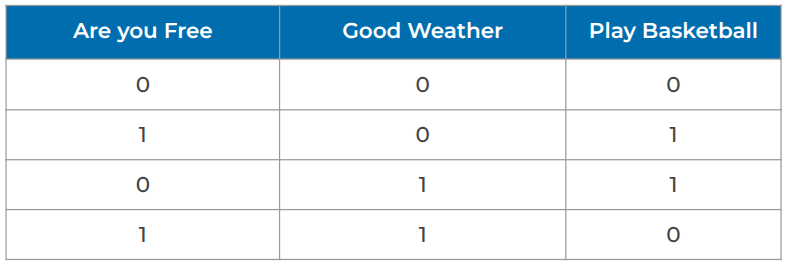

In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
import pandas as pd

In [2]:
def prepare_data():
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    y = np.array([0, 1, 1, 0])
    return X, y

## Step 2: Build the MLP Model 

We use scikit-learn’s MLPClassifier to define the model:

- Hidden Layer Size = 4 neurons
- Activation Function = logistic (sigmoid)
- Solver = lbfgs (optimizer)

Understanding LBFGS

- **LBFGS** stands for Limited-memory Broyden–Fletcher–Goldfarb–Shanno.
- It is an optimizer that updates weights to reduce error.
- It is efficient for small datasets because it uses the full dataset in every iteration (not batch-wise).

Max iterations = 2000

- Limits the number of training steps.
- Prevents excessive computation.
- Training may stop earlier if convergence is reached.

At this point, weights and biases for:
- The hidden layer and Output layer are initialized to small random values.

In [4]:
def build_mlp(hidden_neurons=4, activation='logistic', solver='lbfgs', max_iter=2000):
    model = MLPClassifier(hidden_layer_sizes=(hidden_neurons,),
                          activation=activation,
                          solver=solver,
                          max_iter=max_iter,
                          random_state=42)
    return model

## Step 3: Train the Model

During training:

- Weights and biases are initialized to small random values
- The model adjusts them over multiple iterations
- The goal is to reduce prediction error

In [5]:
def train_model(model, X, y):
    model.fit(X, y)
    return model

## Step 4: Evaluate the Model

After training, we test it on unseen data to measure:
- Accuracy
- Generalization ability
- Whether it’s overfitting or underfitting

In [6]:
def evaluate_model(model, X, y):
    accuracy = model.score(X, y)
    predictions = model.predict(X)
    print(f"Accuracy: {accuracy*100:.2f}%")
    print("Predictions:", predictions)
    return accuracy, predictions

## Step 5: Visualize the Decision Boundary
- Plot the decision boundary to see how the model separates different classes. 
- This helps understand the learned patterns and assess how effectively the model distinguishes between categories.

In [7]:
def plot_decision_boundary(model, X, y, accuracy):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points).reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Plot class 0 points
    plt.scatter(X[y == 0, 0], X[y == 0, 1],
                c='blue', edgecolors='k', s=100, label='Class 0')

    # Plot class 1 points
    plt.scatter(X[y == 1, 0], X[y == 1, 1],
                c='red', edgecolors='k', s=100, label='Class 1')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('MLP Decision Boundary for XOR')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.show()

In [8]:
#Prepare data
X, y = prepare_data()

In [9]:
#Build MLP
mlp_model = build_mlp(hidden_neurons=4, activation='logistic', solver='lbfgs')

In [10]:
#Train model
mlp_model = train_model(mlp_model, X, y)

In [11]:
#Evaluate model
accuracy, predictions = evaluate_model(mlp_model, X, y)

Accuracy: 100.00%
Predictions: [0 1 1 0]


In [14]:
X

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [12]:
df_xor = pd.DataFrame({
    "x₁": X[:, 0],
    "x₂": X[:, 1],
    "Actual": y,
    "Predicted": predictions
})

print("\nXOR Gate Prediction Results:")
display(df_xor)


XOR Gate Prediction Results:


,x₁,x₂,Actual,Predicted
0,0,0,0,0
1,0,1,1,1
2,1,0,1,1
3,1,1,0,0


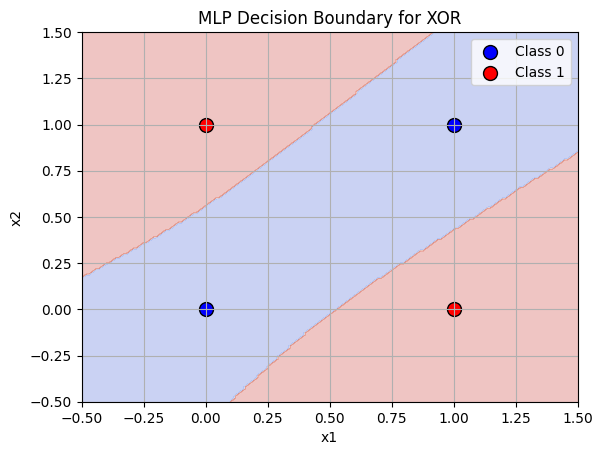

In [13]:
#Visualize model
plot_decision_boundary(mlp_model, X, y, accuracy)